# Acquisizione laser + oscilloscopio (sessione unica)

Laser TLB-6700 e oscilloscopio nello stesso kernel Python, che resta vivo tra le celle (come il workspace MATLAB). Il laser si apre **una volta sola**, l'acquisizione (ultima cella) si può rilanciare più volte.

Il laser usa le stesse chiamate di `NP_USB_connect_velocity.m` e `trigger_scan.m` (indirizzo USB numerico, `OpenDevices(deviceID)`, `Query`/`Write`), con in più solo `SOUR:WAVE:START` e `SOUR:WAVE:STOP`. La velocità di scan resta quella impostata a mano sul laser.

Ordine: celle 1, 2, 3, 4 una volta; poi la cella 5 per ogni acquisizione. Il notebook va aperto dalla sua cartella (`Chiara_Bru/runs_oscilloscope`).

In [1]:
# Cella 1 - configurazione e funzioni dello scope
import os
import sys
import time
import datetime

import numpy as np
import pyvisa
import matplotlib.pyplot as plt

OSC_VISA = "USB::0x0699::0x0408::C028813::INSTR"
OSC_TIMEOUT_MS = 30000

CHANNELS = ["CH1", "CH2"]
LABELS = {"CH1": "CH1 (laser ramp)", "CH2": "CH2 (R spectrum)"}
COLORS = {"CH1": "tab:red", "CH2": "tab:blue"}

LASER_WAVELENGTH_START = 1520.0  # nm, come trigger_scan.m
LASER_WAVELENGTH_STOP = 1570.0   # nm, come trigger_scan.m

POLL_INTERVAL_S = 0.1
CHANNEL_READ_PAUSE_S = 0.1


def crea_cartella_run():
    oggi = datetime.date.today().strftime("%Y-%m-%d")
    base_folder = os.path.join(os.getcwd(), oggi)
    os.makedirs(base_folder, exist_ok=True)
    run_esistenti = [d for d in os.listdir(base_folder) if d.startswith("run_")]
    run_folder = os.path.join(base_folder, f"run_{len(run_esistenti) + 1:03d}")
    os.makedirs(run_folder)
    return run_folder


def configura_scope(osc):
    osc.write("HORizontal:MODE MANUAL")
    rec_len = int(osc.query("HORizontal:RECORDLENGTH?"))
    osc.write("DATA:START 1")
    osc.write(f"DATA:STOP {rec_len}")
    osc.write("DATA:WIDTH 1")
    osc.write("DATA:ENCdg ASCii")


def arm_acquisition(osc):
    osc.write("ACQ:STOPAFTER SEQUENCE")
    osc.write("ACQ:STATE RUN")
    # In ARMED lo scope sta acquisendo il pre-trigger (PrTrig) e ignora i
    # trigger: lo scan parte solo quando lo stato non è più ARMED (READY).
    print("Attendo che lo scope finisca il pre-trigger (ARMED -> READY)...")
    while osc.query("TRIGger:STATE?").strip().upper() != "READY":
        time.sleep(POLL_INTERVAL_S)
        print('waiting...')
    print("Scope pronto ad accettare il trigger.")


def wait_for_acquisition(osc):
    print("Attendo che l'oscilloscopio completi l'acquisizione triggerata...")
    while True:
        if int(osc.query("ACQ:STATE?")) == 0:
            print("Acquisizione completata!")
            break
        time.sleep(POLL_INTERVAL_S)


def acquire_channel(osc, source="CH1"):
    osc.write(f"DATA:SOURCE {source}")
    ymult = float(osc.query("WFMPRE:YMULT?"))
    yoff = float(osc.query("WFMPRE:YOFF?"))
    yzero = float(osc.query("WFMPRE:YZERO?"))
    print(f"{source}: YMULT={ymult}, YOFF={yoff}, YZERO={yzero}")
    raw = osc.query("CURVE?")
    ydata = np.array(raw.split(","), dtype=float)
    return (ydata - yoff) * ymult + yzero

In [2]:
print(osc.query("TRIGger:STATE?").strip().upper())

NameError: name 'osc' is not defined

In [3]:
# Cella 2 - connessione all'oscilloscopio (una volta per sessione)
rm = pyvisa.ResourceManager()
osc = rm.open_resource(OSC_VISA)
osc.timeout = OSC_TIMEOUT_MS
configura_scope(osc)
print("Oscilloscopio connesso e configurato.")

Oscilloscopio connesso e configurato.


In [4]:
# Cella 3 - laser: carica la DLL e apre il dispositivo (una volta per sessione)
USBADDR = 1
DEVICE_ID = 0x100A  # hex2dec('100A')

dll_path = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "scripts", "laser", "UsbDllWrap.dll"))
if not os.path.isfile(dll_path):
    raise RuntimeError(f"UsbDllWrap.dll non trovata in {dll_path} (il notebook va aperto da Chiara_Bru/runs_oscilloscope)")
print(f"DLL trovata: {dll_path}")
sys.path.append(os.path.dirname(dll_path))

import clr
clr.AddReference("UsbDllWrap")
import Newport
from System.Text import StringBuilder

NP_USB = Newport.USBComm.USB()

esito = NP_USB.OpenDevices(DEVICE_ID)
print(f"OpenDevices({hex(DEVICE_ID)}) -> {esito}")
querydata = StringBuilder(64)


def laser_query(comando):
    esito = NP_USB.Query(USBADDR, comando, querydata)
    risposta = querydata.ToString()
    print(f"Query {comando!r} -> esito={esito}, risposta={risposta!r}")
    return risposta


def laser_write(comando):
    esito = NP_USB.Write(USBADDR, comando)
    print(f"Write {comando!r} -> esito={esito}")

DLL trovata: c:\Users\Labo\Desktop\Tesi\scripts\laser\UsbDllWrap.dll
OpenDevices(0x100a) -> True


In [5]:
# Cella 4 - query di stato del laser (rilanciabile quando vuoi)
laser_query("*IDN?")
laser_query("OUTP:STAT?")

Query '*IDN?' -> esito=0, risposta='New_Focus 6700 v2.4 03/19/14 SN23163'
Query 'OUTP:STAT?' -> esito=0, risposta='1'


'1'

I dati saranno salvati in: c:\Users\Labo\Desktop\Tesi\Chiara_Bru\runs_oscilloscope\2026-10-05\run_001
Write 'SOUR:WAVE:START 1520.0' -> esito=0
Write 'SOUR:WAVE:STOP 1570.0' -> esito=0
Attendo che lo scope finisca il pre-trigger (ARMED -> READY)...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
Scope pronto ad accettare il trigger.
Write 'OUTP:SCAN:START' -> esito=0
Attendo che l'oscilloscopio completi l'acquisizione triggerata...
Acquisizione completata!
Leggo CH1...
CH1: YMULT=0.2, YOFF=-75.0, YZERO=0.0
Leggo CH2...
CH2: YMULT=0.02, YOFF=-15.5, YZERO=0.0
Dati salvati in: c:\Users\Labo\Desktop\Tesi\Chiara_Bru\runs_oscilloscope\2026-10-05\run_001\oscilloscope_sweep.csv


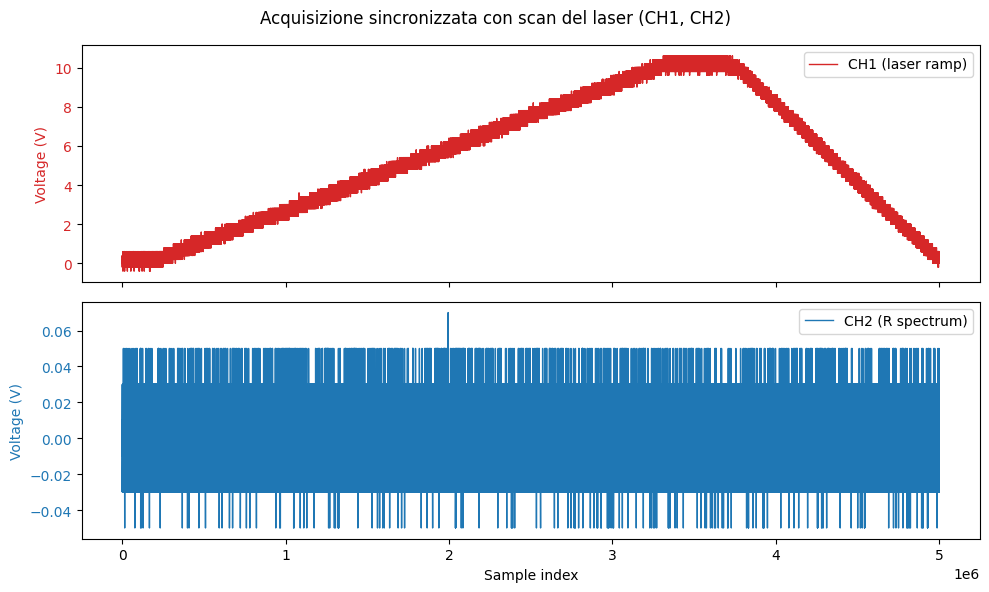

In [6]:
# Cella 5 - UNA acquisizione sincronizzata (rilancia questa cella per ogni acquisizione)
run_folder = crea_cartella_run()
print(f"I dati saranno salvati in: {run_folder}")

laser_write(f"SOUR:WAVE:START {LASER_WAVELENGTH_START}")
laser_write(f"SOUR:WAVE:STOP {LASER_WAVELENGTH_STOP}")

arm_acquisition(osc)
laser_write("OUTP:SCAN:START")

wait_for_acquisition(osc)
time.sleep(1.0)

data = {}
for ch in CHANNELS:
    print(f"Leggo {ch}...")
    data[ch] = acquire_channel(osc, ch)
    time.sleep(CHANNEL_READ_PAUSE_S)

csv_path = os.path.join(run_folder, "oscilloscope_sweep.csv")
min_len = min(len(v) for v in data.values())
all_cols = np.column_stack([data[ch][:min_len] for ch in CHANNELS])
np.savetxt(csv_path, all_cols, delimiter=",", header=",".join(CHANNELS), comments="")
print(f"Dati salvati in: {csv_path}")

fig, axes = plt.subplots(len(CHANNELS), 1, figsize=(10, 6), sharex=True)
for ax, ch in zip(axes, CHANNELS):
    ax.plot(data[ch], color=COLORS[ch], lw=1.0, label=LABELS[ch])
    ax.set_ylabel("Voltage (V)", color=COLORS[ch])
    ax.tick_params(axis="y", labelcolor=COLORS[ch])
    ax.legend(loc="best")
axes[-1].set_xlabel("Sample index")
fig.suptitle(f"Acquisizione sincronizzata con scan del laser ({', '.join(CHANNELS)})")
plt.tight_layout()
plt.show()

Attendo che lo scope finisca il pre-trigger (ARMED -> READY)...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
waiting...
Scope pronto ad accettare il trigger.
Write 'OUTP:SCAN:START' -> esito=0
Attendo che l'oscilloscopio completi l'acquisizione triggerata...
Acquisizione completata!
CH1: YMULT=0.2, YOFF=-75.0, YZERO=0.0
CH1 min/max: -0.4 10.600000000000001
campioni sopra 0.9 V: 4479464 su 5000000 | primo indice: 320421


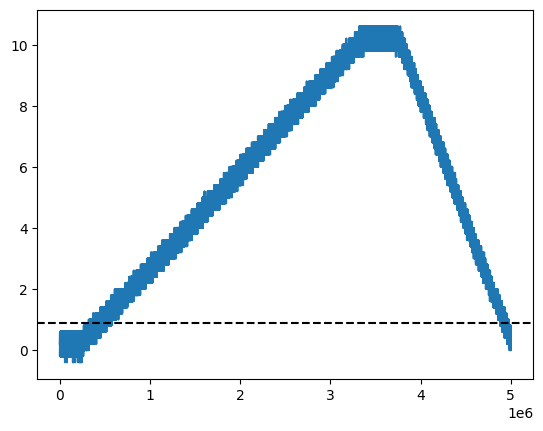

In [6]:
arm_acquisition(osc)
laser_write("OUTP:SCAN:START")
time.sleep(0.5)
osc.write("TRIGger FORCe")
wait_for_acquisition(osc)
time.sleep(0)

ch1 = acquire_channel(osc, "CH1")
print("CH1 min/max:", ch1.min(), ch1.max())
sopra = np.where(ch1 > 0.9)[0]
print("campioni sopra 0.9 V:", len(sopra), "su", len(ch1), "| primo indice:", sopra[0] if len(sopra) else None)

plt.plot(ch1)
plt.axhline(0.9, color="k", ls="--")
plt.show()

In [7]:
arm_acquisition(osc)
print("Scope READY: avvia lo scan a mano sul laser ora")
wait_for_acquisition(osc)

Attendo che lo scope finisca il pre-trigger (ARMED -> READY)...
Scope pronto ad accettare il trigger.
Scope READY: avvia lo scan a mano sul laser ora
Attendo che l'oscilloscopio completi l'acquisizione triggerata...
Acquisizione completata!


In [5]:
S = 3
arm_acquisition(osc)
laser_write("OUTP:SCAN:START")
time.sleep(S)
osc.write("TRIGger FORCe")
wait_for_acquisition(osc)
time.sleep(1.0)

ch1 = acquire_channel(osc, "CH1")
dt = 10.0 / len(ch1)   # record di 10 s (1 s/div x 10 div)
print(f"CH1 supera 50 mV a {np.argmax(ch1 > 0.05) * dt:.2f} s dall'inizio del record")
print(f"CH1 supera 0.9 V a {np.argmax(ch1 > 0.9) * dt:.2f} s")
print(f"Se la rampa parte con lo START, ci si aspetta circa {5 - S:.1f} s")

Attendo che lo scope finisca il pre-trigger (ARMED -> READY)...
Scope pronto ad accettare il trigger.
Write 'OUTP:SCAN:START' -> esito=0
Attendo che l'oscilloscopio completi l'acquisizione triggerata...
Acquisizione completata!
CH1: YMULT=0.2, YOFF=-75.0, YZERO=0.0
CH1 supera 50 mV a 0.00 s dall'inizio del record
CH1 supera 0.9 V a 0.00 s
Se la rampa parte con lo START, ci si aspetta circa 2.0 s


In [ ]:
arm_acquisition(osc)
laser_write("OUTP:SCAN:START")
wait_for_acquisition(osc)

In [ ]:
print(osc.query("TRIGger:A?"))
arm_acquisition(osc)
laser_write("OUTP:SCAN:START")
for i in range(15):
    print(i, "stato scope:", osc.query("TRIGger:STATE?").strip(), "| lambda:", end=" ")
    laser_query("SENS:WAVE?")
    time.sleep(1)

In [ ]:
for q in ["HORizontal:SCAle?", "HORizontal:POSition?", "HORizontal:RECORDLENGTH?", "TRIGger:STATE?"]:
    print(q, "->", osc.query(q).strip())